# Part 1

## Why are you pursuing the MSBA program?

> I am pursuing an MSBA because I wanted to get formal training in technical skills which have broad applications.

## What did you do before entering the program?

> I majored in Political Economy and was a Pre-Med at Tulane University. I was an intern at Kaiser Permanente for three years in a family medicine residency doing data analysis and pipeline automation.

## What type of role, industry, or company are you interested in after graduation?

> Healthcare, Economics, Research. As long as it isn't contributing to the US war-machine and is offering something *tangible* and *beneficial* to the community.

## What topics or methods are you most interested in learning in this course?

> Feature engineering methods aside from random transformations and "just hoping it works."



# Part 2 - Cost of Living & Salary

- rent
- electric
- food
- entertainment
- insurance

In [169]:
import pandas as pd

## clean rental data

In [170]:
zillow_df = pd.read_csv("data/zillow_rentals_city_monthly.csv")

# filter to get three cities
zillow_df = zillow_df[zillow_df['RegionName'].isin(["New Orleans","Austin","San Francisco"])]

# get rid of austin mn
zillow_df = zillow_df[~zillow_df["StateName"].isin(["MN"])]

# wide to long
zillow_df = pd.melt(
    zillow_df,
    id_vars=["RegionName", "StateName"],
    value_vars=["2025-10-31"],
    var_name="Year",
    value_name="AvgRentalPrice"
)

# fix year col
zillow_df["Year"] = zillow_df["Year"].str.split("-").str[0]

# annualize
zillow_df["AnnualRentalCost"] = zillow_df["AvgRentalPrice"] * 12
zillow_df = zillow_df.drop(columns="AvgRentalPrice")

zillow_df

,RegionName,StateName,Year,AnnualRentalCost
0,Austin,TX,2025,18534.543622
1,San Francisco,CA,2025,44397.396405
2,New Orleans,LA,2025,19401.304098


## clean energy data

In [171]:
energy_df = pd.read_csv("data/eia_prices.csv")

# only commercial in CA, TX, and LA in 2026
energy_df['period'] = energy_df['period'].str.split("-").str[0]
energy_df = energy_df[
    (energy_df['stateid'].isin(["CA", "TX", "LA"])) &
    (energy_df['sectorid'] == "COM") &
    (energy_df['period'] == "2025")
]
energy_df = energy_df[['period', 'stateid', 'price']].rename(columns={
    'period': "Year",
    'stateid': "StateName",
    'price': "CentsPerKWh"
})

energy_df = energy_df.groupby(["Year", "StateName"])["CentsPerKWh"].mean().reset_index()

energy_df['AnnualEnergyCost'] = energy_df['CentsPerKWh'] * 10_500 / 100
energy_df = energy_df.drop(columns="CentsPerKWh")

energy_df # avg household uses between 10_500 kwh annually (EIA)

,Year,StateName,AnnualEnergyCost
0,2025,CA,2750.2125
1,2025,LA,1179.1500
2,2025,TX,907.1125


## clean grocery data

In [172]:
grocery_df = pd.read_csv("data/weekly-grocery-prices-by-state-2026.csv")

grocery_df = grocery_df[["state", "GroceryPricesAnnualViaGoBanking_2025"]]
grocery_df = grocery_df[grocery_df['state'].isin(["California", "Texas", "Louisiana"])].reset_index(drop=True)

grocery_df['StateName'] = grocery_df['state'].map({
    "California": "CA",
    "Louisiana": "LA",
    "Texas": "TX"
})

grocery_df = grocery_df.drop(columns=["state"]).rename(columns={"GroceryPricesAnnualViaGoBanking_2025": "AnnualGroceryCost"})
grocery_df

,AnnualGroceryCost,StateName
0,6586.0,CA
1,5853.0,LA
2,5799.0,TX


## entertainment clean

In [173]:
ent_df = pd.read_excel("data/bls_ent_annual.xlsx")
ent_df = ent_df[ent_df["Year"] == 2024]
ent_df = ent_df[["Year", "Estimate"]].rename(columns={"Estimate": "AnnualEntCost"})
ent_df

,Year,AnnualEntCost
10,2024,2540


## healthcare clean

In [174]:
healthcare_df = pd.read_excel("data/bls_healthcare_annual.xlsx")
healthcare_df = healthcare_df[healthcare_df["Year"] == 2024].rename(columns={"Estimate":"AnnualHealthCost"})
healthcare_df

,Year,Period,AnnualHealthCost
10,2024,Annual,2690


## merge

In [175]:
df = zillow_df.merge(energy_df, on=["StateName", "Year"], how="left")
df = df.merge(grocery_df, on="StateName", how="left")
df = df.drop(columns="Year") # i know we are mixing 2024 and 2025 data :(

df['AnnualEntCost'] = ent_df["AnnualEntCost"].values[0]
df['AnnualHealthCost'] = healthcare_df["AnnualHealthCost"].values[0]

# calc final cost
df["Total"] = df["AnnualRentalCost"] + df["AnnualEnergyCost"] + df["AnnualGroceryCost"] + df['AnnualEntCost'] + df["AnnualHealthCost"]

In [176]:
# get required gross income to survive

# https://wallethub.com/edu/best-worst-states-to-be-a-taxpayer/2416
state_tax_rates = {
    "CA": 0.0983,
    "TX": 0.1259,
    "LA": 0.1255,
}

FEDERAL_TAX_RATE = 0.22  # 22% bracket as a magic number

df["EffectiveTaxRate"] = FEDERAL_TAX_RATE + df["StateName"].map(state_tax_rates)
df["RequiredSalary"] = df["Total"] / (1 - df["EffectiveTaxRate"])
df["AmountTaxed"] = df['EffectiveTaxRate'] * df['RequiredSalary']

df

,RegionName,StateName,AnnualRentalCost,AnnualEnergyCost,AnnualGroceryCost,AnnualEntCost,AnnualHealthCost,Total,EffectiveTaxRate,RequiredSalary,AmountTaxed
0,Austin,TX,18534.543622,907.1125,5799.0,2540,2690,30470.656122,0.3459,46584.094362,16113.438240
1,San Francisco,CA,44397.396405,2750.2125,6586.0,2540,2690,58963.608905,0.3183,86494.952185,27531.343281
2,New Orleans,LA,19401.304098,1179.1500,5853.0,2540,2690,31663.454098,0.3455,48378.081127,16714.627029


## visual

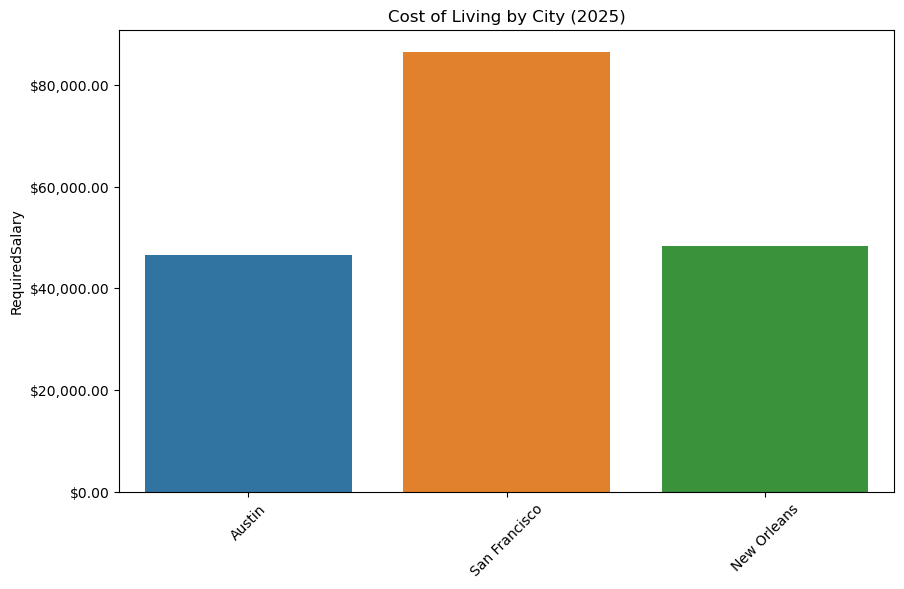

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

plt.title("Cost of Living by City (2025)")

sns.barplot(data=df, x="RegionName", y="RequiredSalary", hue="RegionName", ax=ax)

plt.xticks(rotation=45)
plt.xlabel("")
ax.yaxis.set_major_formatter('${x:,.2f}')

plt.show()

# Part 3

## Did your notebook run successfully from start to finish?

> Yes!

## How long did this assignment take you?

> 1.5 hours

## What is one technical skill you feel confident about, and one you want to strengthen?

> I feel confident transforming data...although it can get a bit messy because I don't always recognize when to use special functions. I want to get quicker at making plots: I loathe Tableau and other data vis software and love how easily I can customize anything about a plot in python (or JS).